# Tennis Action Classifier — YOLOv11-cls
Pipeline: COCO JSON → klasör yapısı → YOLOv11-cls train

In [2]:
# 1. Kurulum
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 94.3 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires nu

In [3]:
# 2. Dataset yapısını incele
import os

BASE = '/kaggle/input/datasets/orvile/tennis-player-actions-dataset/Tennis Player Actions Dataset for Human Pose Estimation'

for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files[:3]:  # ilk 3 dosyayı göster
            print(f'{indent}  {f}')

Tennis Player Actions Dataset for Human Pose Estimation/
  annotations/
    forehand.json
    backhand.json
    serve.json
  images/
    serve/
      S_358.jpeg
      S_078.jpeg
      S_359.jpeg
    backhand/
      B_148.jpeg
      B_418.jpeg
      B_484.jpeg
    forehand/
      F_071.jpeg
      F_051.jpeg
      F_365.jpeg
    ready_position/
      R_104.jpeg
      R_463.jpeg
      R_139.jpeg


In [4]:
# 3. COCO JSON → YOLOv11-cls klasör yapısına dönüşüm
import json
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

# Kaggle dataseti zaten klasörlere ayrılmış olabilir
# Önce kontrol edelim, yoksa JSON'dan oluşturalım

ACTIONS = ['backhand', 'forehand', 'ready_position', 'serve']
OUTPUT_DIR = Path('/kaggle/working/tennis_cls_dataset')

for split in ['train', 'val', 'test']:
    for action in ACTIONS:
        (OUTPUT_DIR / split / action).mkdir(parents=True, exist_ok=True)

print('Klasör yapısı oluşturuldu:')
for split in ['train', 'val', 'test']:
    print(f'  {split}/')
    for action in ACTIONS:
        print(f'    {action}/')

Klasör yapısı oluşturuldu:
  train/
    backhand/
    forehand/
    ready_position/
    serve/
  val/
    backhand/
    forehand/
    ready_position/
    serve/
  test/
    backhand/
    forehand/
    ready_position/
    serve/


In [5]:
# 4. Görüntüleri klasörlere dağıt
# Dataset zaten action klasörlerine ayrılmışsa bu cell'i kullan

import random
random.seed(42)

IMAGES_DIR = Path(BASE) / 'images'

total_copied = 0

for action in ACTIONS:
    action_dir = IMAGES_DIR / action
    
    if not action_dir.exists():
        print(f'UYARI: {action} klasörü bulunamadı, path kontrol et')
        continue
    
    images = list(action_dir.glob('*.jpg')) + \
             list(action_dir.glob('*.jpeg')) + \
             list(action_dir.glob('*.png'))
    
    print(f'{action}: {len(images)} görüntü')
    
    # 70 / 20 / 10 split
    train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.33, random_state=42)
    
    for img in train_imgs:
        shutil.copy(img, OUTPUT_DIR / 'train' / action / img.name)
    for img in val_imgs:
        shutil.copy(img, OUTPUT_DIR / 'val' / action / img.name)
    for img in test_imgs:
        shutil.copy(img, OUTPUT_DIR / 'test' / action / img.name)
    
    total_copied += len(images)

print(f'\nToplam {total_copied} görüntü dağıtıldı')

backhand: 500 görüntü
forehand: 500 görüntü
ready_position: 500 görüntü
serve: 500 görüntü

Toplam 2000 görüntü dağıtıldı


In [6]:
# 5. Split istatistiklerini kontrol et
for split in ['train', 'val', 'test']:
    print(f'\n{split}:')
    total = 0
    for action in ACTIONS:
        count = len(list((OUTPUT_DIR / split / action).glob('*')))
        print(f'  {action}: {count}')
        total += count
    print(f'  TOPLAM: {total}')


train:
  backhand: 350
  forehand: 350
  ready_position: 350
  serve: 350
  TOPLAM: 1400

val:
  backhand: 100
  forehand: 100
  ready_position: 100
  serve: 100
  TOPLAM: 400

test:
  backhand: 50
  forehand: 50
  ready_position: 50
  serve: 50
  TOPLAM: 200


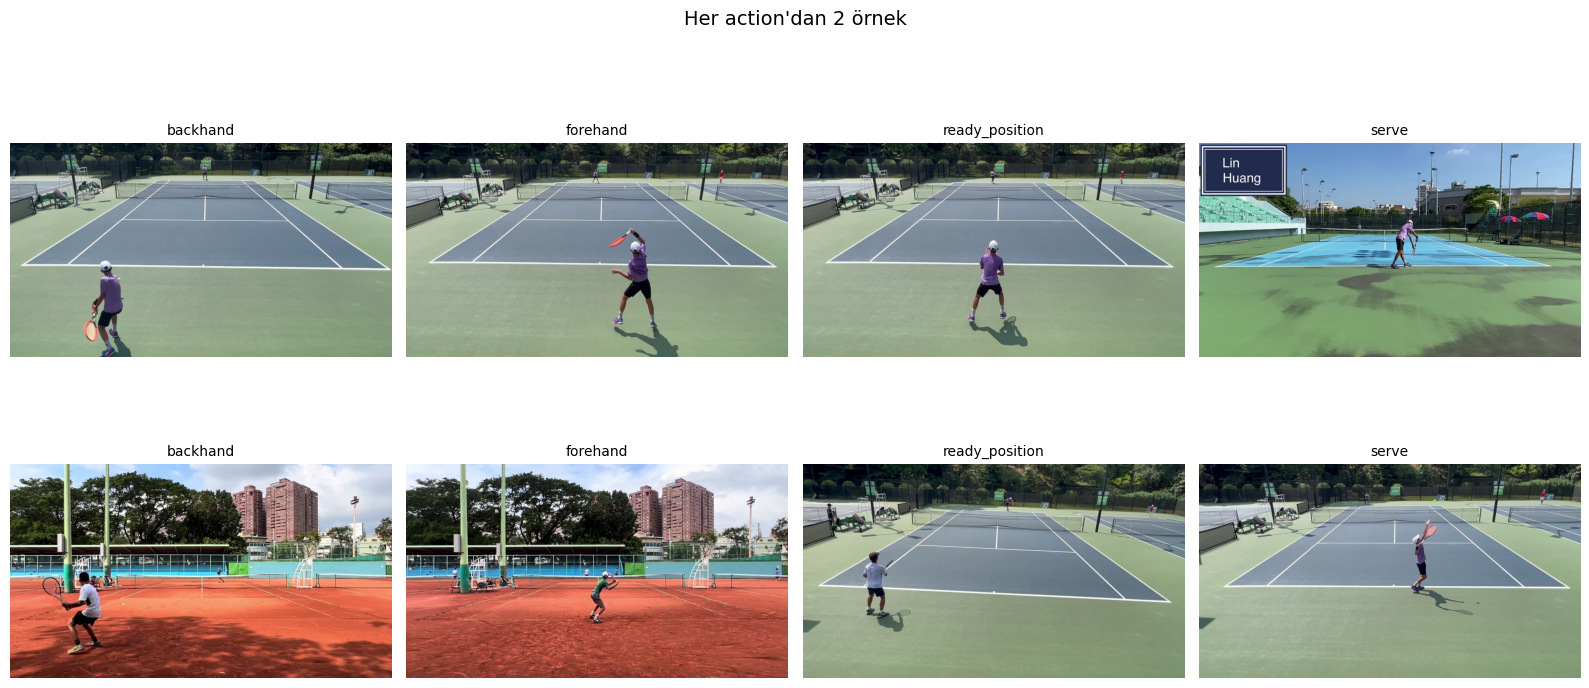

In [7]:
# 6. Örnek görüntülere bak — domain check
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Her action\'dan 2 örnek', fontsize=14)

for col, action in enumerate(ACTIONS):
    imgs = list((OUTPUT_DIR / 'train' / action).glob('*'))[:2]
    for row, img_path in enumerate(imgs):
        img = mpimg.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].set_title(action, fontsize=10)
        axes[row][col].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# 7. YOLOv11-cls Training
from ultralytics import YOLO

model = YOLO('yolo11m-cls.pt')  # Medium, pretrained ImageNet

results = model.train(
    data=str(OUTPUT_DIR),
    epochs=50,
    imgsz=224,        # classification için 224 yeterli
    batch=32,
    patience=10,      # early stopping: 10 epoch iyileşme yoksa dur
    lr0=0.001,
    dropout=0.3,      # 2000 görüntü için overfitting önlemi
    augment=True,
    project='/kaggle/working/runs',
    name='tennis_action_cls',
    exist_ok=True,
    verbose=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/tennis_cls_dataset, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

In [9]:
# 8. Sonuçları değerlendir
metrics = model.val(data=str(OUTPUT_DIR), split='test')

print('\n=== TEST SET SONUÇLARI ===')
print(f'Top-1 Accuracy: {metrics.top1:.3f}')
print(f'Top-5 Accuracy: {metrics.top5:.3f}')

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-cls summary (fused): 57 layers, 10,346,756 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tennis_cls_dataset/train... found 1400 images in 4 classes ✅ 
val: /kaggle/working/tennis_cls_dataset/val... found 400 images in 4 classes ✅ 
test: /kaggle/working/tennis_cls_dataset/test... found 200 images in 4 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1750.1±735.1 MB/s, size: 211.0 KB)
test: Scanning /kaggle/working/tennis_cls_dataset/test... 200 images, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 2.8Kit/s 0.1s
test: New cache created: /kaggle/working/tennis_cls_dataset/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 13/13 7.3it/s 1.8s0.3s
                   all      0.915          1
Speed: 0.2ms preprocess, 2.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val

=== TEST SET SONUÇLARI ===
Top-1 Accur

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-cls summary (fused): 57 layers, 10,346,756 parameters, 0 gradients, 39.3 GFLOPs
train: /kaggle/working/tennis_cls_dataset/train... found 1400 images in 4 classes ✅ 
val: /kaggle/working/tennis_cls_dataset/val... found 400 images in 4 classes ✅ 
test: /kaggle/working/tennis_cls_dataset/test... found 200 images in 4 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3671.5±1069.2 MB/s, size: 212.7 KB)
val: Scanning /kaggle/working/tennis_cls_dataset/val... 400 images, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 152.5Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 25/25 7.4it/s 3.4s0.3s
                   all      0.947          1
Speed: 0.1ms preprocess, 2.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/eval


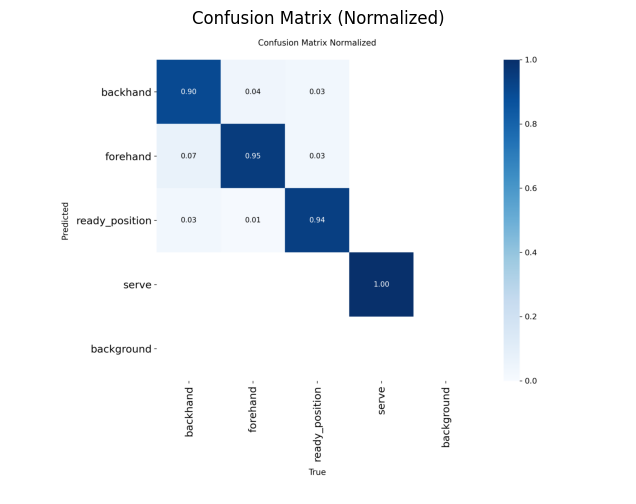

In [10]:
# 9. Confusion matrix — hangi action'lar karışıyor?
from ultralytics import YOLO
import matplotlib.pyplot as plt

# En iyi model weights
best_model = YOLO('/kaggle/working/runs/tennis_action_cls/weights/best.pt')

# Validation üzerinde confusion matrix
best_model.val(
    data=str(OUTPUT_DIR),
    split='val',
    plots=True,
    save_dir='/kaggle/working/eval'
)

# Confusion matrix görseli
cm_path = '/kaggle/working/eval/confusion_matrix_normalized.png'
img = mpimg.imread(cm_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Confusion Matrix (Normalized)')
plt.show()

In [11]:
# 10. Model'i kaydet
import shutil

shutil.copy(
    '/kaggle/working/runs/tennis_action_cls/weights/best.pt',
    '/kaggle/working/tennis_action_classifier_best.pt'
)

print('Model kaydedildi: tennis_action_classifier_best.pt')
print('Bu dosyayı Output sekmesinden indirebilirsin.')

Model kaydedildi: tennis_action_classifier_best.pt
Bu dosyayı Output sekmesinden indirebilirsin.
